# CS6444 Project 1 — R and Graph Analytics
## Stanford Web Graph (2002)

### Team
- Fatulla Bashirov
- Kamal Ahmadov

### Dataset
This project uses the Stanford Web Graph dataset, where each node represents a Stanford University webpage and each directed edge represents a hyperlink from one page to another. The graph is directed and large-scale, which makes it suitable for graph analytics tasks such as centrality, connectivity, clique analysis, ego networks, community detection, and visualization.

### Business / social case
This dataset represents the hyperlink structure of a large academic web domain. From a graph analytics perspective, it can help answer questions such as:
- which pages are the most structurally important,
- how strongly webpages are interconnected,
- whether communities of related pages exist,
- how reachable pages are from one another,
- and how to simplify a very large graph into an interpretable subgraph.

### Assignment goals
In this notebook we will:
1. Load and describe the dataset as a graph.
2. Compute initial graph metrics and properties.
3. Simplify the graph for efficient analysis and explain the simplification.
4. Explore at 10+ additional `igraph` functions.
5. Identify central nodes, longest path interpretation, largest cliques, egos, power centrality, and communities.
6. Produce graph visualizations with captions and interpretation.

In [1]:
# install required packages
install.packages("igraph", repos = "https://cloud.r-project.org")
install.packages("data.table", repos = "https://cloud.r-project.org")

# load libraries
library(igraph)
library(data.table)

# make output more readable
options(width = 120)

also installing the dependencies ‘pkgconfig’, ‘cpp11’





The downloaded binary packages are in
	/var/folders/tj/jbgdbqhd62x4mhtkbl7mm90r0000gn/T//Rtmp6JlNFS/downloaded_packages

The downloaded binary packages are in
	/var/folders/tj/jbgdbqhd62x4mhtkbl7mm90r0000gn/T//Rtmp6JlNFS/downloaded_packages



Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




## 1. Load the data

The Stanford Web Graph file is an edge list. Each row contains a source page ID and a destination page ID, meaning there is a directed hyperlink from the first page to the second page.

Because this is a very large graph, we first load the raw edge list and inspect a small sample before constructing the graph.

In [3]:
# dataset path
# file_path <- "/kaggle/input/datasets/fatullabashirov/stanford-web-graph/web-Stanford.txt" # Path in Kaggle (Submission-ready)
file_path <- "./data/web-Stanford.txt" # Local path (for testing)

# read edge list
edges <- fread(
  file_path,
  sep = "\t",
  header = FALSE,
  comment.char = "#",
  col.names = c("from", "to")
)

# inspect the data
dim(edges)
head(edges)
summary(edges)

[1] 2312497       2

from,to
<int>,<int>
1,6548
1,15409
6548,57031
15409,13102
2,17794
2,25202


      from              to        
 Min.   :     1   Min.   :     2  
 1st Qu.: 70779   1st Qu.: 73100  
 Median :141051   Median :143725  
 Mean   :140961   Mean   :143950  
 3rd Qu.:211225   3rd Qu.:218070  
 Max.   :281903   Max.   :281903  

## 2. Build the directed graph

The graph is created as a directed graph because hyperlinks have direction: a page can link to another page without receiving a link back.

In [4]:
# build directed graph from edge list
g <- graph_from_data_frame(edges, directed = TRUE)

# basic summary
g
cat("Number of vertices:", vcount(g), "\n")
cat("Number of edges:", ecount(g), "\n")
cat("Is directed:", is_directed(g), "\n")
cat("Has loops:", any_loop(g), "\n")

IGRAPH d6bcc88 DN-- 281903 2312497 -- 
+ attr: name (v/c)
+ edges from d6bcc88 (vertex names):
 [1] 1     ->6548   1     ->15409  6548  ->57031  15409 ->13102  2     ->17794  2     ->25202  2     ->53625 
 [8] 2     ->54582  2     ->64930  2     ->73764  2     ->84477  2     ->98628  2     ->100193 2     ->102355
[15] 2     ->105318 2     ->105730 2     ->115926 2     ->140864 2     ->163550 2     ->164599 2     ->175799
[22] 2     ->178642 2     ->181714 2     ->190453 2     ->204189 2     ->204604 2     ->210870 2     ->213966
[29] 2     ->225119 2     ->241596 2     ->243294 2     ->246897 2     ->251658 2     ->252915 2     ->280935
[36] 252915->2      246897->2      246897->78056  251658->2      280935->2      213966->2      213966->47149 
[43] 243294->2      225119->2      241596->2      178642->2      210870->2      204189->2      190453->2     
[50] 204604->2      181714->2      164599->2      175799->2      163550->2      140864->2      115926->2     
+ ... omitted several edg

Number of vertices: 281903 
Number of edges: 2312497 
Is directed: TRUE 
Has loops: FALSE 


## 3. Initial graph properties

The project requires reporting metrics and properties of the initial graph, including number of nodes, edges, sparsity, directedness, and structural characteristics.

In [5]:
# basic graph properties
n <- vcount(g)
m <- ecount(g)

density_val <- edge_density(g, loops = FALSE)

# for directed graph without loops, max possible edges = n * (n - 1)
max_possible_edges <- n * (n - 1)
sparsity_val <- 1 - (m / max_possible_edges)

cat("Vertices:", n, "\n")
cat("Edges:", m, "\n")
cat("Density:", density_val, "\n")
cat("Sparsity:", sparsity_val, "\n")
cat("Directed (arrowness):", is_directed(g), "\n")

Vertices: 281903 
Edges: 2312497 
Density: 2.909935e-05 
Sparsity: 0.9999709 
Directed (arrowness): TRUE 


In [5]:
# degree summaries
deg_in <- degree(g, mode = "in")
deg_out <- degree(g, mode = "out")
deg_all <- degree(g, mode = "all")

summary(deg_in)
summary(deg_out)
summary(deg_all)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0     1.0     2.0     8.2     4.0 38606.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   2.000   5.000   8.203   9.000 255.000 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    1.00     5.00     8.00    16.41    12.00 38626.00 

### Interpretation

The results show that this is a very sparse directed graph. Its density is approximately 0.000029, while sparsity is about 0.99997, meaning only a tiny fraction of all possible page-to-page hyperlinks actually exist. This is expected for a web graph, since each webpage links to only a small subset of all pages in the domain.

The graph is directed, so in-degree and out-degree describe different roles. In-degree measures how many pages link to a page, while out-degree measures how many pages a page links to. The average in-degree and out-degree are both about 8.2, which is consistent with a directed edge list.

The degree summaries also show strong inequality in connectivity. For example, the median in-degree is only 2, but the maximum in-degree is 38,606. Similarly, the median out-degree is 5, while the maximum out-degree is 255. This suggests that most pages have relatively few links, while a small number of pages act as major hubs or highly referenced pages.

In [6]:
# connectivity structure
wcc <- components(as_undirected(g, mode = "collapse"))
scc <- components(g, mode = "strong")

cat("Number of weakly connected components:", wcc$no, "\n")
cat("Size of largest WCC:", max(wcc$csize), "\n")
cat("Number of strongly connected components:", scc$no, "\n")
cat("Size of largest SCC:", max(scc$csize), "\n")

Number of weakly connected components: 365 


Size of largest WCC: 255265 


Number of strongly connected components: 29914 


Size of largest SCC: 150532 


## Initial visualization attempt

Before simplifying the graph, we attempted to visualize the original network to understand whether the full graph could be interpreted directly.

Because the graph contains 281,903 vertices and 2,312,497 edges, the full visualization is expected to be highly dense and difficult to read. This step is useful as a baseline because it shows why simplification is necessary for meaningful graphical analysis.

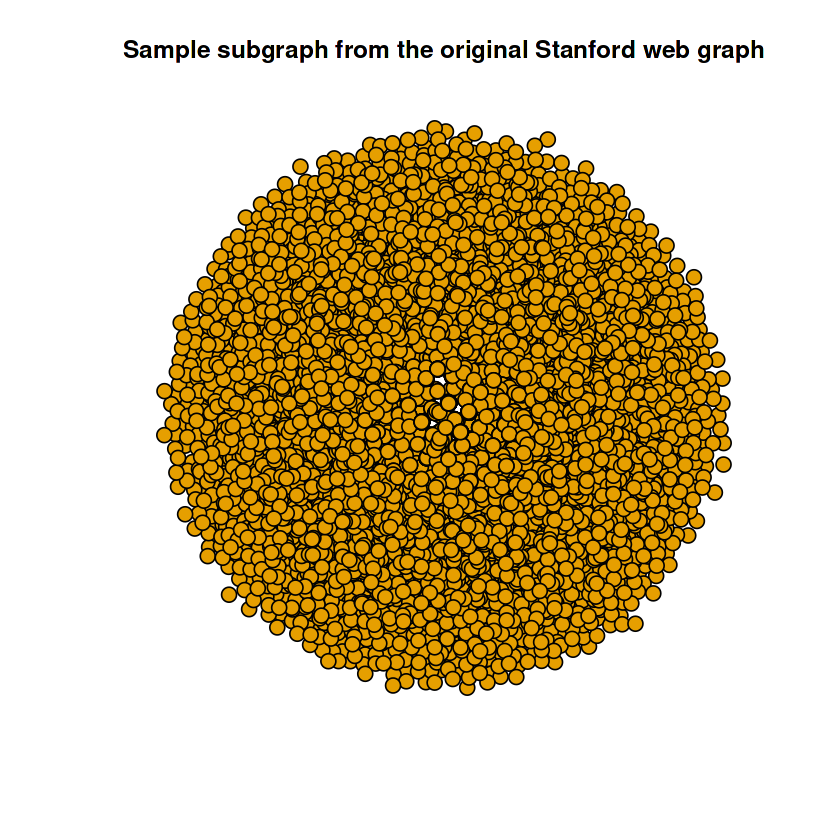

In [7]:
sample_nodes <- sample(V(g), 10000)
g_sample_original <- induced_subgraph(g, sample_nodes)

plot(
  g_sample_original,
  vertex.size = 5,
  vertex.label = NA,
  edge.arrow.size = 0.2,
  main = "Sample subgraph from the original Stanford web graph"
)